--- Baseline(Without cylindrical projection) Quantitative assessment ---
The number of internal points involved in the calculation: 193
Average re-projection error (Mean Error): 2.3069 pixels
Maximum re-projection error (Max Error): 5.5292 pixels
Root Mean Square Error(RMSE): 2.5991 pixels
--------------------------------------


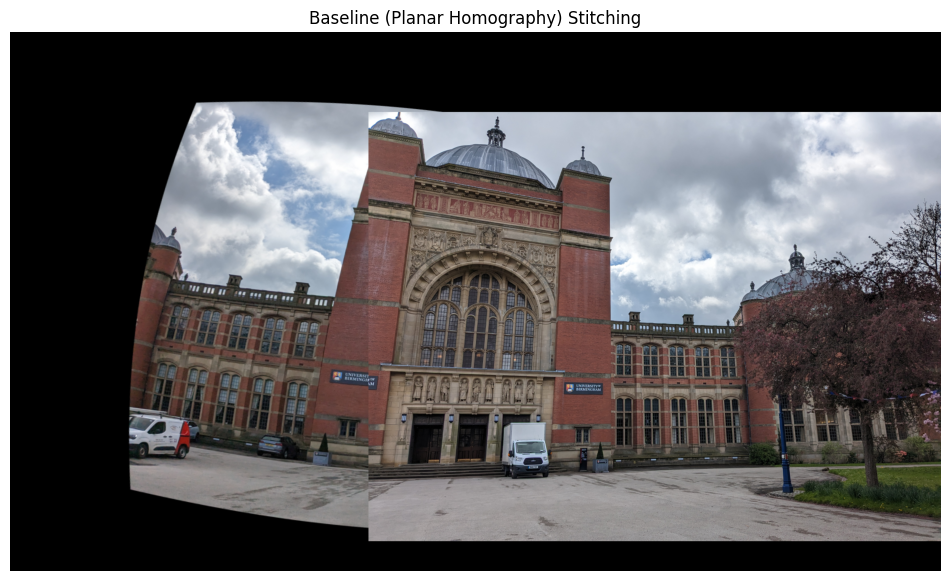

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取与预处理 (不使用柱面投影！)
img1 = cv2.imread('UOB1.jpg') 
img2 = cv2.imread('UOB2.jpg')

if img1 is None or img2 is None:
    raise ValueError("The image cannot be found. Please check the path!")

# 缩小图像防内存溢出
scale_percent = 30 
width1 = int(img1.shape[1] * scale_percent / 100)
height1 = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width1, height1), interpolation=cv2.INTER_AREA)
width2 = int(img2.shape[1] * scale_percent / 100)
height2 = int(img2.shape[0] * scale_percent / 100)
img2 = cv2.resize(img2, (width2, height2), interpolation=cv2.INTER_AREA)

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 2. SIFT 提取与匹配
sift = cv2.SIFT_create(nfeatures=2000) 
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

if len(good_matches) > 4:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

    # 3. 计算单应性矩阵 (核心步骤)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # ==========================================
    # 🌟 新增：重投影误差定量评估模块 🌟
    # ==========================================
    # 只提取被 RANSAC 认定为“内点”的坐标
    inlier_src_pts = src_pts[mask.ravel() == 1]
    inlier_dst_pts = dst_pts[mask.ravel() == 1]

    # 用算出的 H 矩阵去预测图 1 的点在图 2 的位置
    projected_src_pts = cv2.perspectiveTransform(inlier_src_pts, H)

    # 计算预测位置和实际位置的欧氏距离
    errors = np.linalg.norm(projected_src_pts.squeeze() - inlier_dst_pts.squeeze(), axis=1)

    # 计算统计数据
    mean_error = np.mean(errors)
    max_error = np.max(errors)
    rmse_error = np.sqrt(np.mean(errors**2))

    print("--- Baseline(Without cylindrical projection) Quantitative assessment ---")
    print(f"The number of internal points involved in the calculation: {len(inlier_src_pts)}")
    print(f"Average re-projection error (Mean Error): {mean_error:.4f} pixels")
    print(f"Maximum re-projection error (Max Error): {max_error:.4f} pixels")
    print(f"Root Mean Square Error(RMSE): {rmse_error:.4f} pixels")
    print("--------------------------------------")
    # ==========================================

    # 4. 图像变换与拼接 (带平移矩阵防裁剪版)
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    warped_corners_img1 = cv2.perspectiveTransform(corners_img1, H)

    all_corners = np.concatenate((warped_corners_img1, corners_img2), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    t_x = -x_min if x_min < 0 else 0
    t_y = -y_min if y_min < 0 else 0

    T = np.array([[1, 0, t_x],
                  [0, 1, t_y],
                  [0, 0, 1]], dtype=np.float32)

    canvas_width = x_max - x_min
    canvas_height = y_max - y_min

    H_translation = T.dot(H)
    
    result = cv2.warpPerspective(img1_rgb, H_translation, (canvas_width, canvas_height))
    result_img2 = cv2.warpPerspective(img2_rgb, T, (canvas_width, canvas_height))
    
    gray_result_img2 = cv2.cvtColor(result_img2, cv2.COLOR_RGB2GRAY)
    mask_img2 = (gray_result_img2 > 0)
    result[mask_img2] = result_img2[mask_img2]

    plt.figure(figsize=(15, 7))
    plt.imshow(result)
    plt.title("Baseline (Planar Homography) Stitching")
    plt.axis('off')
    plt.show()

else:
    print("No sufficient matching points were found.")

--- Baseline(Without cylindrical projection) Quantitative assessment ---
The number of internal points involved in the calculation: 15
Average re-projection error (Mean Error): 1.2351 pixels
Maximum re-projection error (Max Error): 3.0028 pixels
Root Mean Square Error(RMSE): 1.4010 pixels
--------------------------------------


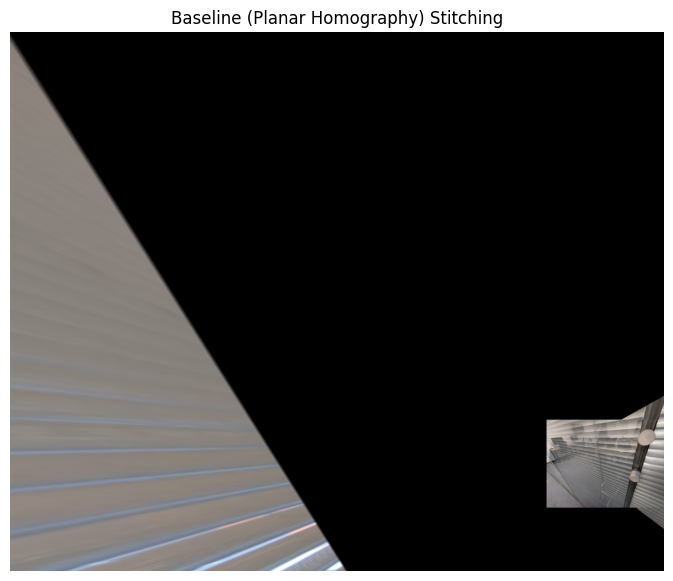

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取与预处理 (不使用柱面投影！)
img1 = cv2.imread('Door1.jpeg') 
img2 = cv2.imread('Door2.jpeg')

if img1 is None or img2 is None:
    raise ValueError("The image cannot be found. Please check the path!")

# 缩小图像防内存溢出
scale_percent = 30 
width1 = int(img1.shape[1] * scale_percent / 100)
height1 = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width1, height1), interpolation=cv2.INTER_AREA)
width2 = int(img2.shape[1] * scale_percent / 100)
height2 = int(img2.shape[0] * scale_percent / 100)
img2 = cv2.resize(img2, (width2, height2), interpolation=cv2.INTER_AREA)

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 2. SIFT 提取与匹配
sift = cv2.SIFT_create(nfeatures=2000) 
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.6 * n.distance:
        good_matches.append(m)

if len(good_matches) > 4:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

    # 3. 计算单应性矩阵 (核心步骤)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # ==========================================
    # 🌟 新增：重投影误差定量评估模块 🌟
    # ==========================================
    # 只提取被 RANSAC 认定为“内点”的坐标
    inlier_src_pts = src_pts[mask.ravel() == 1]
    inlier_dst_pts = dst_pts[mask.ravel() == 1]

    # 用算出的 H 矩阵去预测图 1 的点在图 2 的位置
    projected_src_pts = cv2.perspectiveTransform(inlier_src_pts, H)

    # 计算预测位置和实际位置的欧氏距离
    errors = np.linalg.norm(projected_src_pts.squeeze() - inlier_dst_pts.squeeze(), axis=1)

    # 计算统计数据
    mean_error = np.mean(errors)
    max_error = np.max(errors)
    rmse_error = np.sqrt(np.mean(errors**2))

    print("--- Baseline(Without cylindrical projection) Quantitative assessment ---")
    print(f"The number of internal points involved in the calculation: {len(inlier_src_pts)}")
    print(f"Average re-projection error (Mean Error): {mean_error:.4f} pixels")
    print(f"Maximum re-projection error (Max Error): {max_error:.4f} pixels")
    print(f"Root Mean Square Error(RMSE): {rmse_error:.4f} pixels")
    print("--------------------------------------"
    # ==========================================

    # 4. 图像变换与拼接 (带平移矩阵防裁剪版)
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    warped_corners_img1 = cv2.perspectiveTransform(corners_img1, H)

    all_corners = np.concatenate((warped_corners_img1, corners_img2), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    t_x = -x_min if x_min < 0 else 0
    t_y = -y_min if y_min < 0 else 0

    T = np.array([[1, 0, t_x],
                  [0, 1, t_y],
                  [0, 0, 1]], dtype=np.float32)

    canvas_width = x_max - x_min
    canvas_height = y_max - y_min

    H_translation = T.dot(H)
    
    result = cv2.warpPerspective(img1_rgb, H_translation, (canvas_width, canvas_height))
    result_img2 = cv2.warpPerspective(img2_rgb, T, (canvas_width, canvas_height))
    
    gray_result_img2 = cv2.cvtColor(result_img2, cv2.COLOR_RGB2GRAY)
    mask_img2 = (gray_result_img2 > 0)
    result[mask_img2] = result_img2[mask_img2]

    plt.figure(figsize=(15, 7))
    plt.imshow(result)
    plt.title("Baseline (Planar Homography) Stitching")
    plt.axis('off')
    plt.show()

else:
    print("No sufficient matching points were found.")

After rigorous screening, the number of surviving high-quality matching points: 10
The attempted generated canvas size: 1450 x 1071
--- Task 2 (Door) Quantitative Evaluation Results ---
Number of Inliers: 10
Mean Reprojection Error: 0.6889 pixels
Root Mean Square Error: 0.9283 pixels
---------------------------------


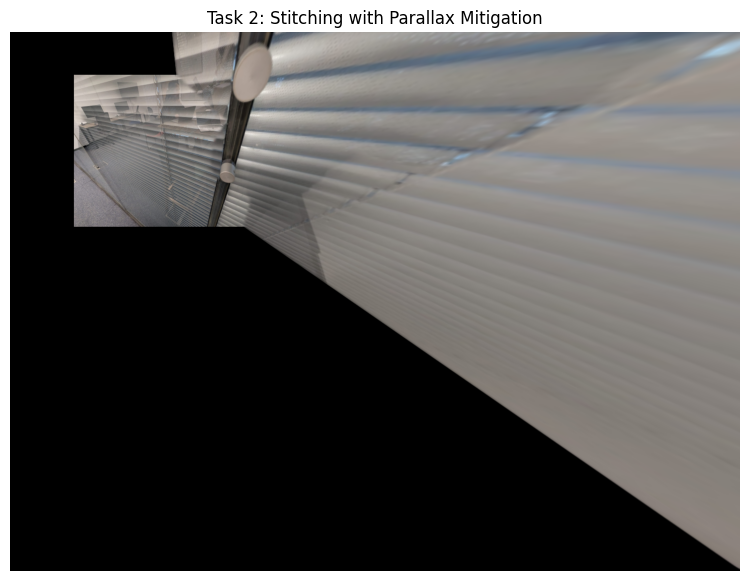

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('Door1.jpg') 
img2 = cv2.imread('Door2.jpg')

if img1 is None or img2 is None:
    raise ValueError("找不到图片，请检查路径！")

# 【优化 1：进一步缩小图像到 20%，降低计算压力】
scale_percent = 20 
width1 = int(img1.shape[1] * scale_percent / 100)
height1 = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width1, height1), interpolation=cv2.INTER_AREA)
width2 = int(img2.shape[1] * scale_percent / 100)
height2 = int(img2.shape[0] * scale_percent / 100)
img2 = cv2.resize(img2, (width2, height2), interpolation=cv2.INTER_AREA)

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create(nfeatures=2000) 
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
# 【优化 2：把 0.6 稍微放宽到 0.7，防止因为点太少导致 H 矩阵算错】
for m, n in matches:
    if m.distance < 0.5 * n.distance:
        good_matches.append(m)

print(f"After rigorous screening, the number of surviving high-quality matching points: {len(good_matches)}")

if len(good_matches) > 4:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

    # 尝试将 RANSAC 阈值设为 4.0
    try:
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.USAC_MAGSAC, 5.0)
    except AttributeError:
        # Fallback 备用方案
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.LMEDS)

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    warped_corners_img1 = cv2.perspectiveTransform(corners_img1, H)

    all_corners = np.concatenate((warped_corners_img1, corners_img2), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    t_x = -x_min if x_min < 0 else 0
    t_y = -y_min if y_min < 0 else 0

    T = np.array([[1, 0, t_x],
                  [0, 1, t_y],
                  [0, 0, 1]], dtype=np.float32)

    canvas_width = x_max - x_min
    canvas_height = y_max - y_min
    
    # ==========================================
    # 🚨 核心防爆锁：阻止内存溢出 🚨
    # ==========================================
    print(f"The attempted generated canvas size: {canvas_width} x {canvas_height}")
    if canvas_width > 10000 or canvas_height > 10000:
        raise ValueError("安全拦截：画布尺寸大得离谱！说明算出的单应性矩阵 H 是错的（畸变严重）。请在代码里尝试调整 Lowe's ratio (比如 0.6 到 0.8) 或 RANSAC 阈值！")
    # ==========================================

    H_translation = T.dot(H)

    # === Task 2 定量评估模块 ===
    # 1. 提取 RANSAC 选出的优质内点
    inlier_src_pts = src_pts[mask.ravel() == 1]
    inlier_dst_pts = dst_pts[mask.ravel() == 1]

    # 2. 计算重投影
    projected_src_pts = cv2.perspectiveTransform(inlier_src_pts, H)

    # 3. 计算每个点的欧氏距离误差
    errors = np.linalg.norm(projected_src_pts.squeeze() - inlier_dst_pts.squeeze(), axis=1)

    # 4. 统计指标
    mean_error = np.mean(errors)
    rmse_error = np.sqrt(np.mean(errors**2))

    print("--- Task 2 (Door) Quantitative Evaluation Results ---")
    print(f"Number of Inliers: {len(inlier_src_pts)}")
    print(f"Mean Reprojection Error: {mean_error:.4f} pixels")
    print(f"Root Mean Square Error: {rmse_error:.4f} pixels")
    print("---------------------------------")

    warped_img1 = cv2.warpPerspective(img1_rgb, H_translation, (canvas_width, canvas_height))
    warped_img2 = cv2.warpPerspective(img2_rgb, T, (canvas_width, canvas_height))

    mask1 = (cv2.cvtColor(warped_img1, cv2.COLOR_RGB2GRAY) > 0).astype(np.uint8)
    mask2 = (cv2.cvtColor(warped_img2, cv2.COLOR_RGB2GRAY) > 0).astype(np.uint8)

    dist1 = cv2.distanceTransform(mask1, cv2.DIST_L2, 3)
    dist2 = cv2.distanceTransform(mask2, cv2.DIST_L2, 3)

    hard_mask1 = (dist1 > dist2).astype(np.float32)
    
    smooth_mask1 = cv2.GaussianBlur(hard_mask1, (15, 15), 0)
    smooth_mask2 = 1.0 - smooth_mask1

    weight1 = cv2.merge([smooth_mask1, smooth_mask1, smooth_mask1])
    weight2 = cv2.merge([smooth_mask2, smooth_mask2, smooth_mask2])

    blended_result = warped_img1 * weight1 + warped_img2 * weight2
    blended_result = blended_result.astype(np.uint8)

    plt.figure(figsize=(15, 7))
    plt.imshow(blended_result)
    plt.title("Task 2: Stitching with Parallax Mitigation")
    plt.axis('off')
    plt.show()

else:
    print("Not enough matches")